# Moondream to describe microscopy image content

[Moondream](https://github.com/vikhyat/moondream) is a tiny vision-language model with intriguing characteristics: it’s lightweight, fast, and runs locally - meaning your data is not transmitted elsewhere. 

But can moondream help to gain insights from biological images? Bio-image analysis is a field where computer scientists and biologists need to work together to built lasting sustainable workflows. Therefore, it would be handy to have tools like moondream to help bridge the knowledge gap between computer scientists and biologists.

## Installation

Windows:
* Download vips-dev-w64-all-8.16.1.zip from [here](https://github.com/libvips/build-win64-mxe/releases/tag/v8.16.1), unzip it, and add its subfolder `bin` to the PATH environment variable.
* `pip install einops pyvips`

Mac:
* `conda install -c conda-forge libvips`
* `pip install einops pyvips`

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image
from skimage import data, img_as_ubyte
import numpy as np
import stackview
import matplotlib.pyplot as plt

The transformer library contains a powerful set of tools like `AutoModelForCausalLM`, the pretrained moondream model. Hereby, causal language modeling (CLM) is utilized, meaning it is trained to generate text autoregressively. This comes in handy for image captioning, where the model outputs a full, coherent description of what is detected in the image. This description could facilitate domain-specific knowledge exchange, for example the biological context of certain microscopy images.

Another tool is `AutoTokenizer`. The task of the tokenizer is to handle encoding and decoding of human-readable text into numerical format required by the model. Basically, the tokenizer ensures that the prompt is accurately interpreted by the model.

In [2]:
model = AutoModelForCausalLM.from_pretrained(
    "vikhyatk/moondream2",
    revision="2025-01-09",
    trust_remote_code=True,
    # Comment to run on CPU. To use the GPU, you need about 5 GB of GPU Memory.
    # GPU "cuda"
    # On Apple Silicon, use "mps"
    device_map={"": "mps"}
)

tokenizer = AutoTokenizer.from_pretrained(
    "vikhyatk/moondream2",
    revision="2025-01-09",
    trust_remote_code=True
)

## Describing image content 

Let us first load our image provided by the skimage library. We use a slice of a 3D data set and utilize the nuclei channel.

> Van der Walt, S., Schönberger, J.L., Nunez-Iglesias, J. et al. scikit-image: image processing in Python. PeerJ 2, e453 (2014). https://doi.org/10.7717/peerj.453

StackViewNDArray([[ 8868,  6923,  5690, ..., 13942, 12804, 14653],
                  [ 7113,  5501,  5216, ..., 16739, 13657, 15554],
                  [ 5833,  7160,  5928, ..., 15838, 16739, 17166],
                  ...,
                  [ 2513,  3936,  3414, ...,  3699,  4126,  4220],
                  [ 3319,  3272,  2513, ...,  3699,  3367,  2940],
                  [ 3130,  3794,  3225, ...,  2987,  3746,  4315]],
                 shape=(256, 256), dtype=uint16)
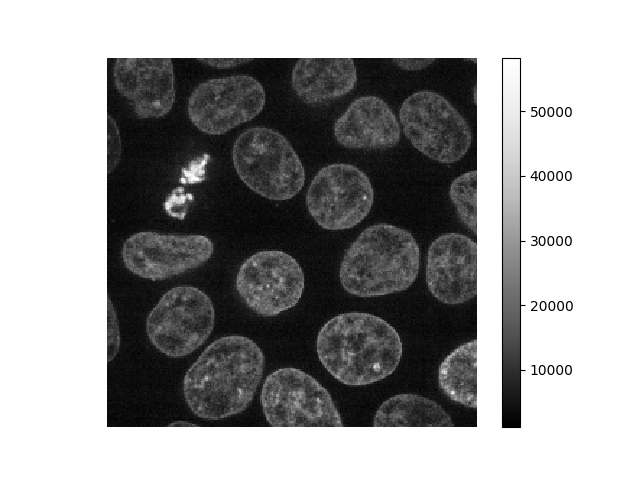
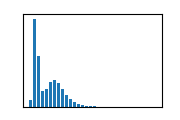

In [3]:
# Load the microscopy image
nuclei = data.cells3d()[30, 1, :, :]
stackview.insight(nuclei)

To prepare the microscopy image for analysis with Moondream, it must first be converted into a compatible format. The image is transformed to 8-bit unsigned integers (`img_as_ubyte`) to ensure pixel values fall within the expected range (0–255), then wrapped in a PIL Image object (`Image.fromarray`) since Moondream’s encoder requires this format. Finally, the image is passed to `model.encode_image`, which converts it into a feature representation the model can interpret for tasks such as captioning or question answering.

In [4]:
nuclei_uint8 = img_as_ubyte(nuclei)
pil_nuclei = Image.fromarray(nuclei_uint8)
encoded_nuclei = model.encode_image(pil_nuclei)

In [5]:
# Generate caption
caption = model.caption(encoded_nuclei)["caption"]
print("Caption:", caption)

Caption:  The image presents a microscopic view of a dark background, speckled with numerous small, round, grayish-white cells. The cells are scattered across the image, with some cells appearing slightly larger than others. The cells are not uniformly distributed, with some areas having a higher concentration than others. The image is captured in grayscale, with the cells exhibiting a range of gray shades.


In [6]:
# Ask questions
answer = model.query(encoded_nuclei, "What's in this image?")["answer"]
print("Answer:", answer)

Answer:  The image is a black and white microscopic view of a group of cells. The cells are arranged in a somewhat random pattern, with some overlapping each other. The cells vary in size and shape, and some appear to have a slightly irregular or amorphous form. The overall composition of the image is a close-up view of the cells, providing a detailed look at their structure and arrangement.


The caption generated by Moondream illustrates the model’s strength in detailed visual observation. It accurately describes structural and spatial features such as contrast, distribution, and shape. 

However, the caption remains purely descriptive — it lacks biological interpretation. Terms like “mitotic figures” or “nuclei” are absent, reflecting the model’s limited domain-specific knowledge. This highlights a key gap between general-purpose vision-language models and the specialized understanding required for biomedical image analysis.

## Counting nuclei

Beyond its ability to generate text, the model also offers functionality that may be particularly relevant for quantitative tasks. Specifically, moondream can localize and count objects in images by returning coordinate points that correspond to instances of a prompted object. Therefore, let us explore the models ability to count objects in a microscopy image.

In [ ]:
# Pointing
print("\nPointing: 'bright spot'")
points_nuclei = model.point(encoded_nuclei, "Mark the large round nuclei in the image")["points"]
print(f"Found {len(points_nuclei)} bright spot(s)")


Pointing: 'round nuclei'
Found 50 round nuclei.


In [9]:
box_half_size_nuclei = 5 / nuclei_uint8.shape[0]
bb_nuclei = [{'x':p['x']-box_half_size_nuclei, 'y':p['y']-box_half_size_nuclei, 'width':2*box_half_size_nuclei, 'height':2*box_half_size_nuclei } for p in points_nuclei]

StackViewNDArray([[[34, 34, 34],
                   [26, 26, 26],
                   [20, 20, 20],
                   ...,
                   [57, 57, 57],
                   [52, 52, 52],
                   [60, 60, 60]],

                  [[26, 26, 26],
                   [19, 19, 19],
                   [18, 18, 18],
                   ...,
                   [69, 69, 69],
                   [56, 56, 56],
                   [64, 64, 64]],

                  [[20, 20, 20],
                   [26, 26, 26],
                   [21, 21, 21],
                   ...,
                   [65, 65, 65],
                   [69, 69, 69],
                   [72, 72, 72]],

                  ...,

                  [[ 5,  5,  5],
                   [12, 12, 12],
                   [10, 10, 10],
                   ...,
                   [11, 11, 11],
                   [13, 13, 13],
                   [13, 13, 13]],

                  [[ 9,  9,  9],
                   [ 9,  9,  9],
                   [ 5,  5,  5],
                   ...,
                   [11, 11, 11],
                   [10, 10, 10],
                   [ 8,  8,  8]],

                  [[ 9,  9,  9],
                   [11, 11, 11],
                   [ 9,  9,  9],
                   ...,
                   [ 8,  8,  8],
                   [11, 11, 11],
                   [13, 13, 13]]], shape=(256, 256, 3), dtype=uint8)
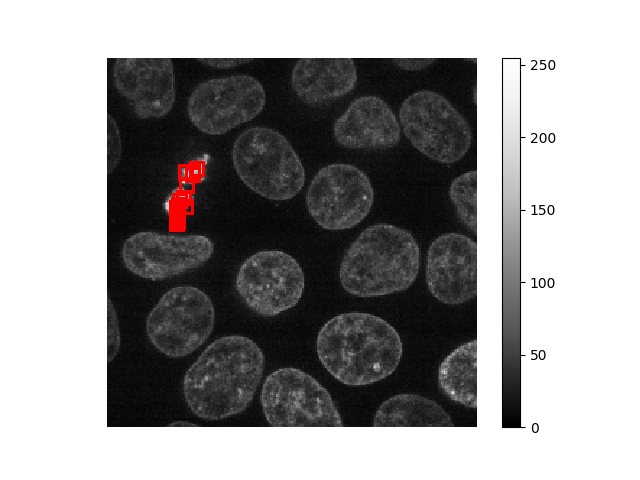
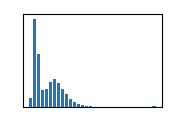

In [10]:
stackview.add_bounding_boxes(nuclei_uint8, bb_nuclei)

We see that all the large and round objects in the image are detected.

## Distinguising different cell types in images

But can moondream also identify different cell types? To investigate this question let us move on to another dataset provided by [Zeki Kuş et al. 2024](https://zenodo.org/records/10523421) and licensed [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/legalcode). It contains blood cells extracted from whole slide images.

Let us first load the image:

StackViewNDArray([[[255, 255, 255],
                   [253, 253, 253],
                   [255, 255, 255],
                   ...,
                   [135, 115, 117],
                   [134, 114, 115],
                   [133, 113, 112]],

                  [[255, 255, 255],
                   [252, 252, 252],
                   [255, 255, 255],
                   ...,
                   [135, 117, 113],
                   [134, 117, 109],
                   [134, 117, 107]],

                  [[254, 254, 254],
                   [253, 253, 253],
                   [255, 255, 255],
                   ...,
                   [135, 121, 108],
                   [134, 121, 105],
                   [133, 120, 103]],

                  ...,

                  [[253, 253, 253],
                   [255, 255, 255],
                   [255, 254, 255],
                   ...,
                   [255, 255, 255],
                   [255, 255, 255],
                   [255, 255, 255]],

                  [[253, 253, 253],
                   [255, 255, 255],
                   [255, 253, 254],
                   ...,
                   [255, 255, 255],
                   [255, 255, 255],
                   [255, 255, 255]],

                  [[255, 255, 255],
                   [255, 255, 255],
                   [242, 240, 241],
                   ...,
                   [255, 255, 255],
                   [255, 255, 255],
                   [255, 255, 255]]], shape=(1368, 1712, 3), dtype=uint8)
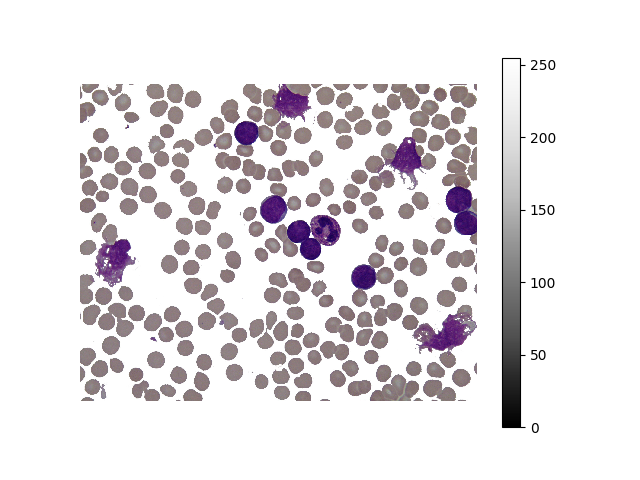
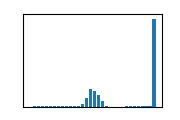

In [12]:
blood_cells = Image.open("Im004.jpg")
blood_cells = np.array(blood_cells)
stackview.insight(blood_cells)

The larger purple cells are most likely white blood cells, specifically lymphocytes or other leukocytes, stained with Wright-Giemsa. The smaller light grey-brown cells are probably red blood cells as they ofter appear lighter and more uniform in color because they lack a nucleus.

In [13]:
blood_cells_uint8 = img_as_ubyte(blood_cells)
pil_blood_cells = Image.fromarray(blood_cells_uint8)
encoded_blood_cells = model.encode_image(pil_blood_cells)

In [14]:
# Pointing
print("\nPointing: 'bright spot'")
points_blood_cells = model.point(encoded_blood_cells, "Identify and mark all large violet objects of round shape spread across the image.")["points"]
print(f"Found {len(points_blood_cells)} bright spot(s)")


Pointing: 'bright spot'
Found 11 bright spot(s)


In [15]:
height, width = blood_cells.shape[:2]

points_blood_cells_px = [
    {
        'x': int(p['x'] * width),
        'y': int(p['y'] * height)
    }
    for p in points_blood_cells
]

box_half_size = 15  # increase from 5
bb_blood_cells = [
    {
        'x': p['x'] - box_half_size,
        'y': p['y'] - box_half_size,
        'width': 2 * box_half_size,
        'height': 2 * box_half_size
    }
    for p in points_blood_cells_px
]

In [16]:
print(points_blood_cells[:5])

[{'x': 0.0849609375, 'y': 0.5439453125}, {'x': 0.5, 'y': 0.060546875}, {'x': 0.8310546875, 'y': 0.2314453125}, {'x': 0.95703125, 'y': 0.3662109375}, {'x': 0.9677734375, 'y': 0.43359375}]


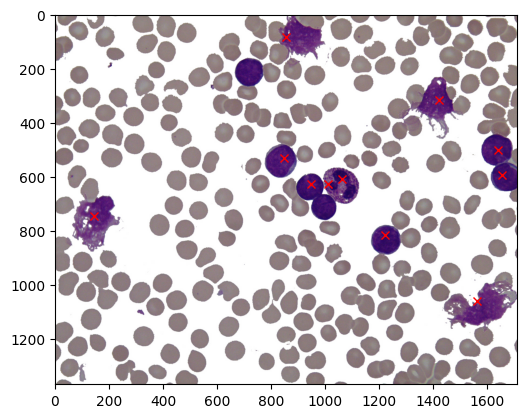

In [17]:
plt.imshow(blood_cells, cmap='gray')
for p in points_blood_cells_px:
    plt.plot(p['x'], p['y'], 'rx')  # red crosses at predicted points
plt.show()

This looks reasonable, can it also identify the bursted white blood cells which might be due to cell lysis or damage during sample preparation?

In [18]:
# Pointing
print("\nPointing: 'bright spot'")
points_damaged_cells = model.point(encoded_blood_cells, "Identify and mark all big violet cells that are damaged.")["points"]
print(f"Found {len(points_damaged_cells)} bright spot(s)")


Pointing: 'bright spot'
Found 3 bright spot(s)


In [19]:
height, width = blood_cells.shape[:2]

points_damaged_cells_px = [
    {
        'x': int(p['x'] * width),
        'y': int(p['y'] * height)
    }
    for p in points_damaged_cells
]

box_half_size = 15  # increase from 5
bb_blood_cells = [
    {
        'x': p['x'] - box_half_size,
        'y': p['y'] - box_half_size,
        'width': 2 * box_half_size,
        'height': 2 * box_half_size
    }
    for p in points_damaged_cells_px
]

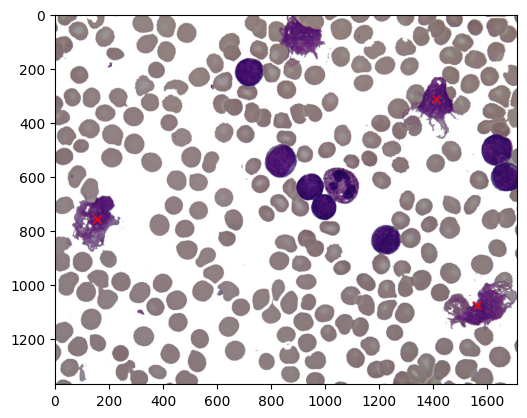

In [20]:
plt.imshow(blood_cells, cmap='gray')
for p in points_damaged_cells_px:
    plt.plot(p['x'], p['y'], 'rx')  # red crosses at predicted points
plt.show()

## Limitations

And what about our red blood cells?

In [21]:
# Pointing
print("\nPointing: 'bright spot'")
points_smaller_cells = model.point(encoded_blood_cells, "Identify and mark all big grey objects of round shape spread across the image that are not violet.")["points"]
print(f"Found {len(points_smaller_cells)} bright spot(s)")


Pointing: 'bright spot'
Found 50 bright spot(s)


In [22]:
height, width = blood_cells.shape[:2]

points_smaller_cells_px = [
    {
        'x': int(p['x'] * width),
        'y': int(p['y'] * height)
    }
    for p in points_smaller_cells
]

box_half_size = 15  # increase from 5
bb_smaller_cells = [
    {
        'x': p['x'] - box_half_size,
        'y': p['y'] - box_half_size,
        'width': 2 * box_half_size,
        'height': 2 * box_half_size
    }
    for p in points_smaller_cells_px
]

In [23]:
print(points_smaller_cells[:5])

[{'x': 0.2138671875, 'y': 0.9052734375}, {'x': 0.2763671875, 'y': 0.849609375}, {'x': 0.3544921875, 'y': 0.8984375}, {'x': 0.408203125, 'y': 0.875}, {'x': 0.46875, 'y': 0.935546875}]


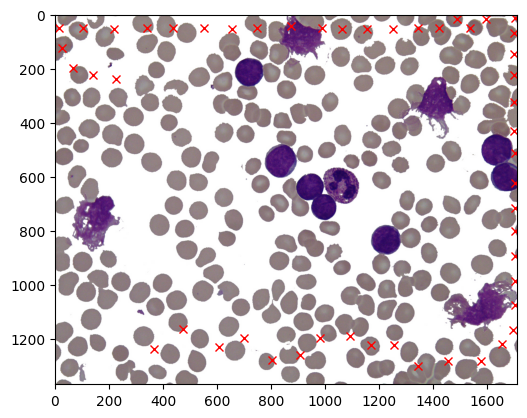

In [24]:
plt.imshow(blood_cells, cmap='gray')
for p in points_smaller_cells_px:
    plt.plot(p['x'], p['y'], 'rx')  # red crosses at predicted points
plt.show()

Interestingly, Moondream struggles to reliably detect and count red blood cells in the image. Additionally, the number of detected counted objects is significantly lower than the actual number of nuclei present. This limitation arises because Moondream has an internal cap and cannot count more than 50 objects per image.

## Conclusion

While Moondream is not a specialized biomedical model, its success in morphological filtering and object counting from microscopy images reflects the transformative potential of [AI in Life Science and Medicine](https://scads.ai/research/applied-ai-and-big-data/life-science-and-medicine/) like here at [ScaDS.AI](https://scads.ai). Moondream illustrates a broader movement in the research area of Life Science and Medicine, where AI is used to augment clinical insight, reduce manual workload, and democratize data analysis pipelines. In line with ongoing work in biosignal processing, genomic data interpretation, and data harmonization, even simple models like Moondream help show how intelligent systems can contribute to more efficient, accessible, and scalable medical research workflows.

## Further reading

* [Moondream github repository](https://github.com/vikhyat/moondream)
* [Moondream on huggingface](https://huggingface.co/vikhyatk/moondream2)
* [Getting started with Vision Language Model: Moondream with code by Indradumna Banerjee](https://medium.com/@indradumnabanerjee/getting-started-with-vision-language-model-moondream-783c264a02b9)